## Pipeline Element Influence
Analyse der Pipeline-Komponenten fuer Geschlechtsmodelle.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
from joblib import dump

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import SummaryWrapper
from FIT_python.general_pipeline_steps.feature_selection_wrapper import FeatureSelectionTransformer
from FIT_python.general_pipeline_steps.outlier_wrapper import OutlierCleanerTransformer
from FIT_python.general_pipeline_steps.feature_scaler_wrapper import FeatureScalerTransformer
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.general_pipeline_steps.models import MODELS
from FIT_python.data_split_and_summary.transform_wrapper import NumericTransformer
from FIT_python.plot_style import apply_style
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer

apply_style()

EXP_DIR = Path("experiments/experiments/pipeline_element_influence")
EXP_DIR.mkdir(parents=True, exist_ok=True)


## Create Splits
Alle Rohdaten werden geladen und in Trainings-, Test- und Inferenz-Splits unter EXP_DIR/splits gespeichert.

✔️ Fold-Spalte in aj_someringii schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     98
1    112
2     90

📊 aj_someringii – train – 300 Zeilen | 20 Individuen | 43 Trails
sex
m    153
f    147

📊 aj_someringii – test – 70 Zeilen | 5 Individuen | 10 Trails
sex
f    42
m    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    169
1    164
2    143

📊 amur_tiger – train – 476 Zeilen | 35 Individuen | 68 Trails
sex
f    260
m    216

📊 amur_tiger – test – 129 Zeilen | 9 Individuen | 19 Trails
sex
f    84
m    45

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     95
1    201
2    128

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – train – 395 Zeilen | 27 Individuen | 54 Trails
sex
f    220
m    175

📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✔️ Fold-Spalte in giant_panda schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     88
1    144
2    172

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 61 Trails
sex
f    238
m    166

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 16 Trails
sex
f    63
m    56

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✔️ Fold-Spalte in jubatus schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    153
1    147
2    147

📊 jubatus – train – 447 Zeilen | 32 Individuen | 64 Trails
sex
f    258
m    189

📊 jubatus – test – 119 Zeilen | 8 Individuen |

0

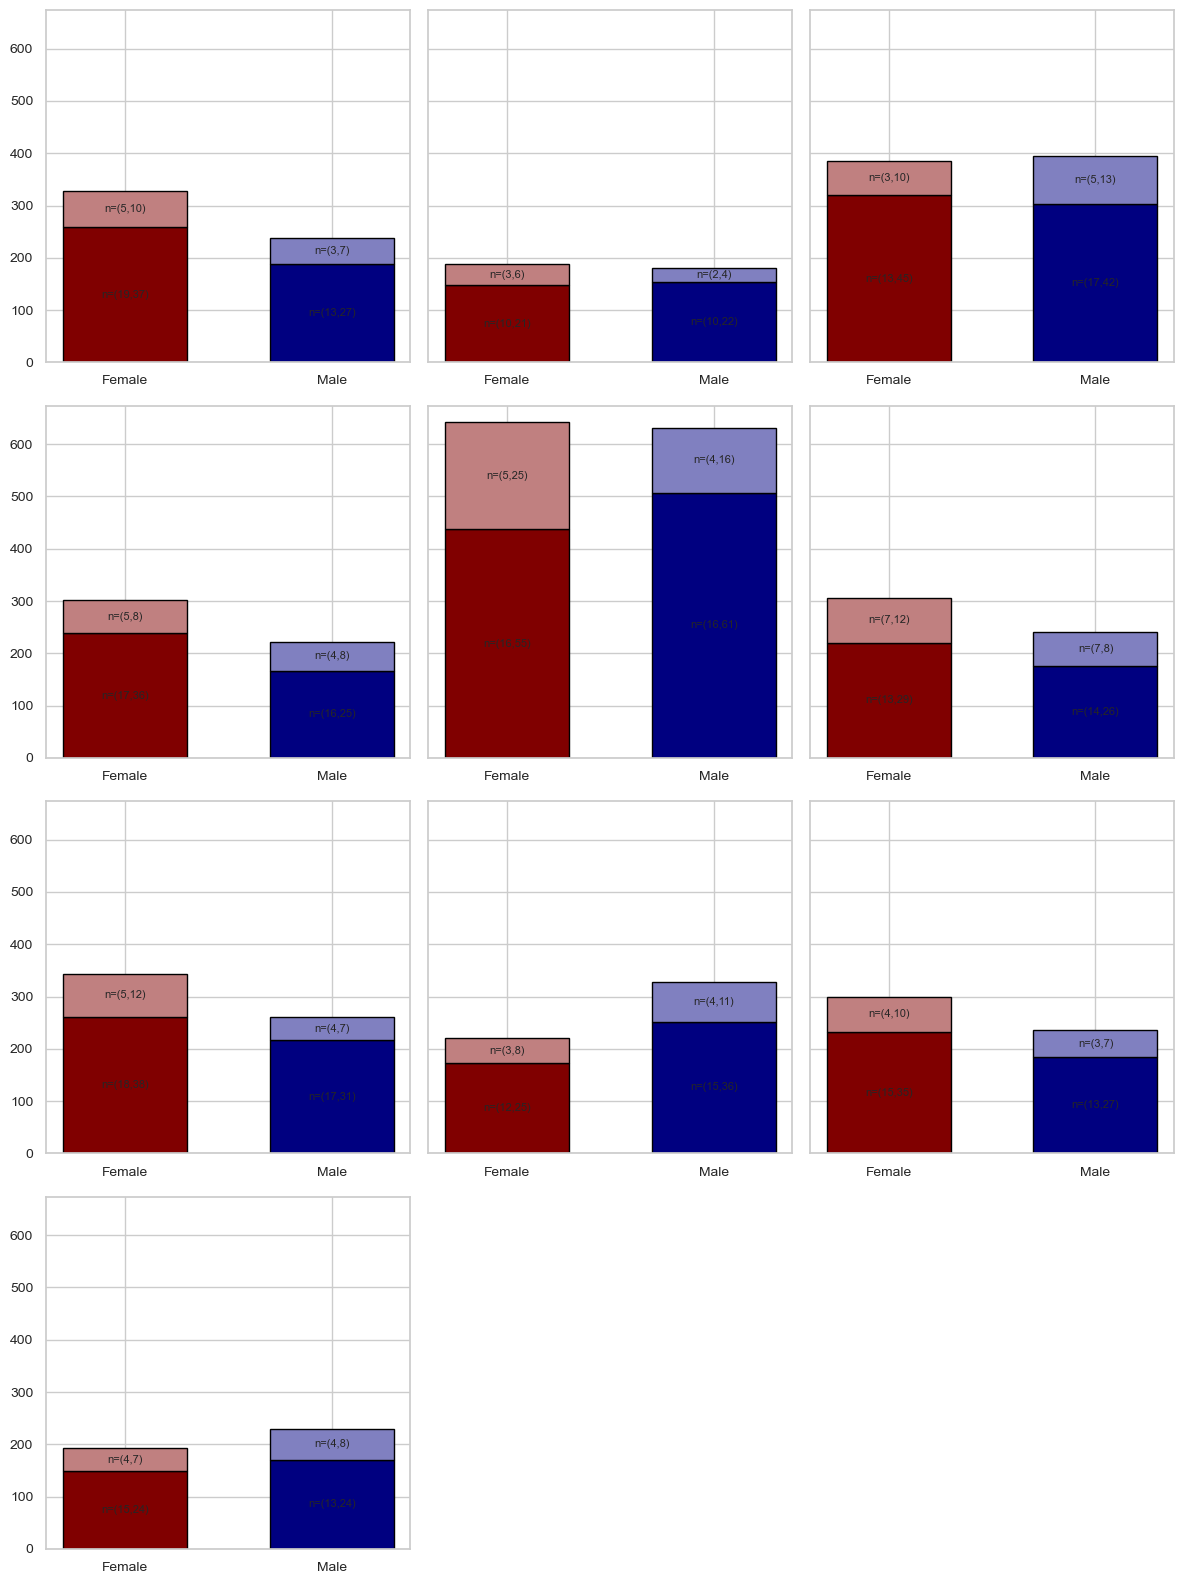

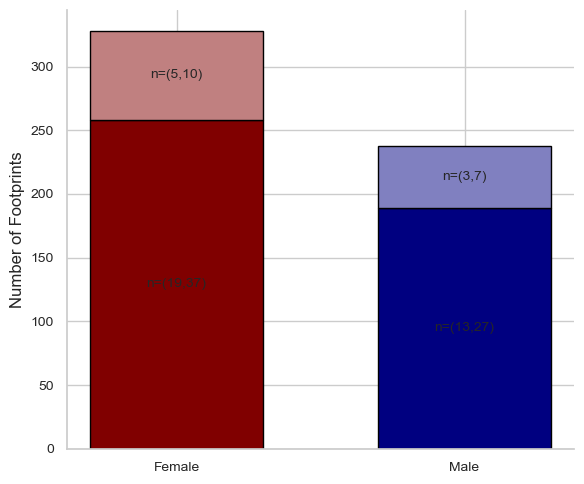

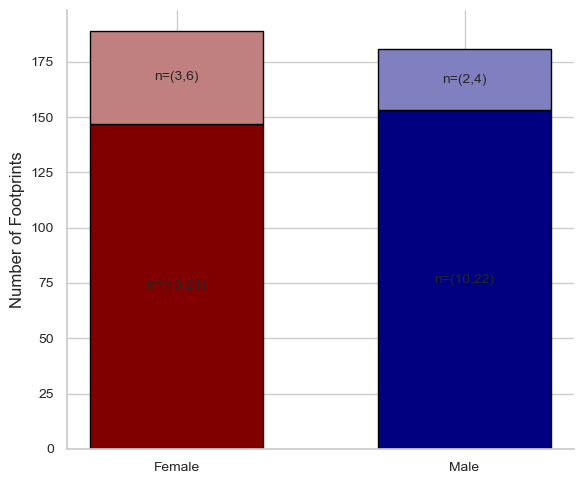

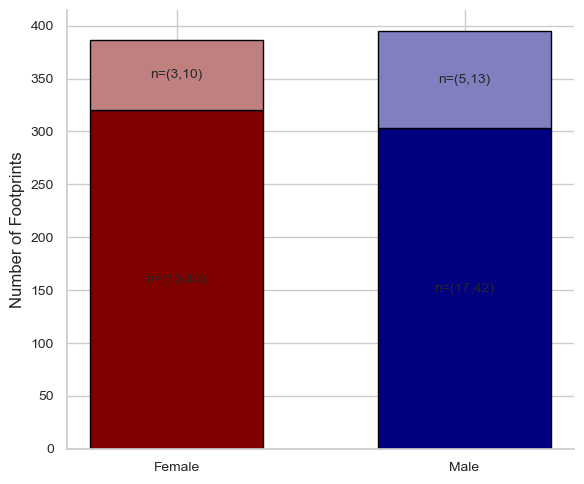

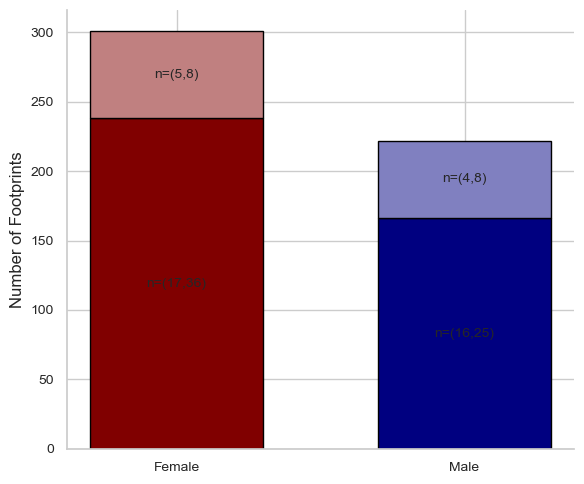

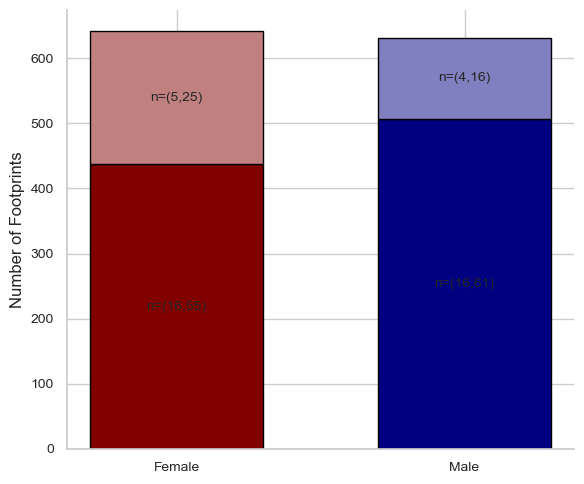

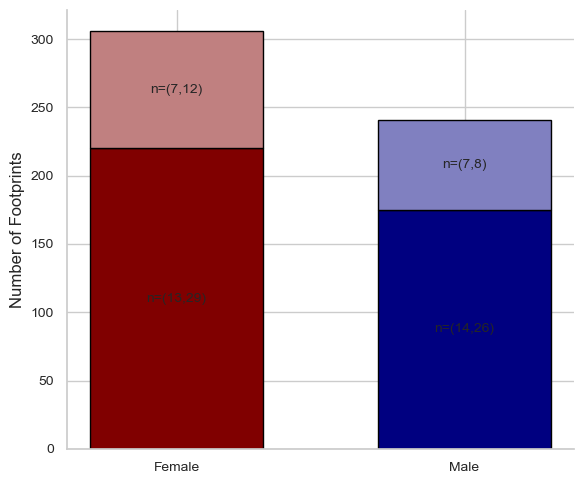

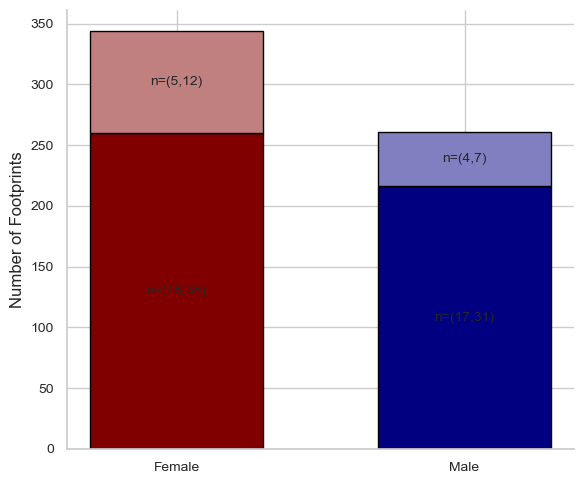

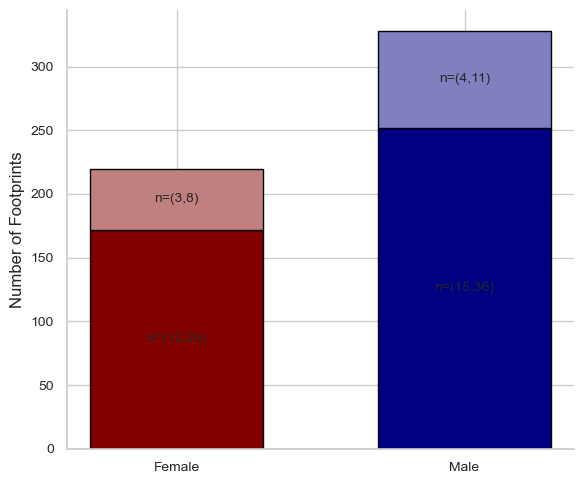

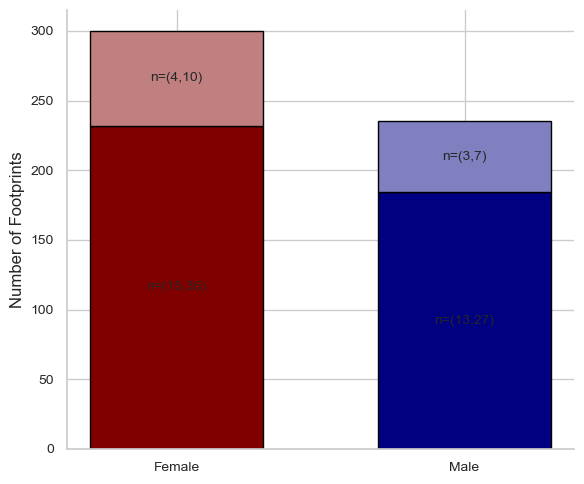

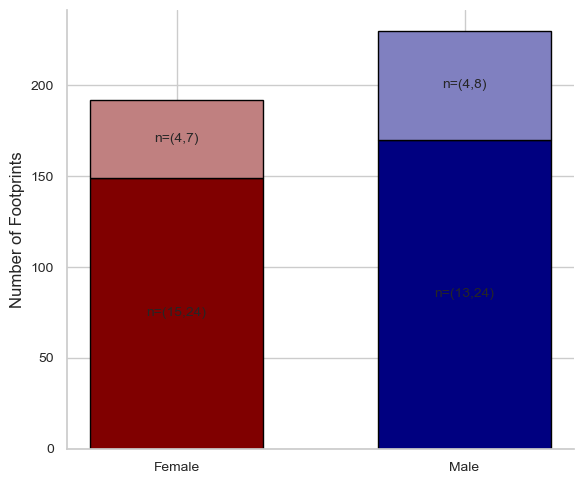

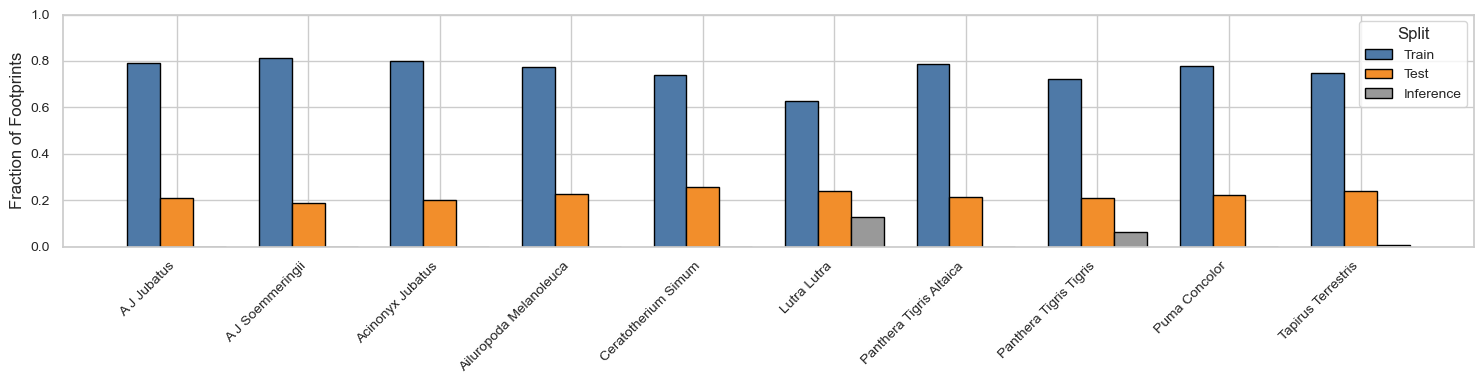

In [2]:
split_dir = EXP_DIR / "splits"
SplitWrapper(output_dir=split_dir).split_all(as_csv=True)
SummaryWrapper().summarize_all(splits_dir=split_dir, output_table=EXP_DIR/"split_summary.csv", fig_dir=EXP_DIR/"split_figs")


## Bayesian Hyperparameter Search
BayesSearchCV untersucht verschiedene Pipelineelemente.

In [3]:
results = []
search_records = []
pipe_template = Pipeline([
    ("numeric", NumericTransformer()),
    ("outlier", "passthrough"),
    ("scale", "passthrough"),
    ("select", FeatureSelectionTransformer()),
    ("reduce_pre", "passthrough"),
    ("clf", MODELS["logreg_l2"]),
])
search_space = {
    "outlier": Categorical([
        "passthrough",
        OutlierCleanerTransformer(method="clip"),
        OutlierCleanerTransformer(method="zscore"),
    ], transform="identity"),
    "scale": Categorical([
        "passthrough",
        FeatureScalerTransformer(method="standard"),
        FeatureScalerTransformer(method="robust"),
    ], transform="identity"),
    "select": Categorical([
        "passthrough",
        FeatureSelectionTransformer(method="forward", k=5),
        FeatureSelectionTransformer(method="forward", k=10),
        FeatureSelectionTransformer(method="lasso", k=10),
    ], transform="identity"),
    "reduce_pre": Categorical([
        "passthrough",
        DimensionalityReducerTransformer(method="pca", n_components=5),
        DimensionalityReducerTransformer(method="umap", n_components=5),
    ], transform="identity"),
    "clf": Categorical([
        MODELS["logreg_l2"],
        MODELS["rf_small"],
        MODELS["xgb_hist"],
    ], transform="identity"),
}

split_dir = EXP_DIR / "splits"
for sp in sorted(split_dir.iterdir()):
    if not sp.is_dir():
        continue
    train_fp = sp / "train.parquet"
    test_fp = sp / "test.parquet"
    if not train_fp.exists() or not test_fp.exists():
        continue
    train_df = pd.read_parquet(train_fp)
    test_df = pd.read_parquet(test_fp)
    num_cols = train_df.select_dtypes(include=np.number).columns
    feature_cols = [c for c in num_cols if c != "Fold"]
    X_tr = train_df[feature_cols]
    y_tr = train_df["sex"].map({"f":0,"m":1})
    X_te = test_df[feature_cols]
    y_te = test_df["sex"].map({"f":0,"m":1})
    cv = PredefinedSplit(train_df["Fold"]) if "Fold" in train_df.columns else 3
    bayes = BayesSearchCV(
        estimator=pipe_template,
        search_spaces=search_space,
        n_iter=20,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )
    bayes.fit(X_tr, y_tr)
    best_model = bayes.best_estimator_
    preds = best_model.predict(X_te)
    test_acc = balanced_accuracy_score(y_te, preds)
    dump(best_model, EXP_DIR / f"{sp.name}_best_model.joblib")
    pd.DataFrame(bayes.cv_results_).to_csv(EXP_DIR / f"{sp.name}_search.csv", index=False)
    results.append({
        "species": sp.name,
        "cv_best_balanced_accuracy": bayes.best_score_,
        "test_balanced_accuracy": test_acc,
    })
    search_records.append(pd.DataFrame(bayes.cv_results_).assign(species=sp.name))

results_df = pd.DataFrame(results)
results_df.to_csv(EXP_DIR / "results_summary.csv", index=False)
search_df = pd.concat(search_records, ignore_index=True)
search_df.to_csv(EXP_DIR / "search_details.csv", index=False)


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: F

## Visualisation
Nutze Hilfsfunktionen fuer einheitliche Darstellungen.

In [4]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import plot_hyperparam_heatmap
plot_hyperparam_heatmap(search_df.rename(columns={
    "select__method": "fs_method",
    "reduce_pre__method": "reduce_pre_method",
    "mean_test_score": "cv_balanced_accuracy"}), EXP_DIR / "figs")


[CAPTION] Mean CV accuracy by selector and reducer


WindowsPath('experiments/experiments/pipeline_element_influence/figs/hyperparam_heatmap.png')

## LLM ready results
Die wichtigsten Kennzahlen werden in einer kompakten CSV gespeichert.

In [5]:
llm_file = EXP_DIR / "llm_results.txt"
with llm_file.open("w", encoding="utf-8") as f:
    for row in results:
        f.write(
            f"{row['species']}: CV={row['cv_best_balanced_accuracy']:.3f}, Test={row['test_balanced_accuracy']:.3f}
"
        )
llm_file


SyntaxError: unterminated string literal (detected at line 5) (3678843679.py, line 5)